In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('homework_2.2.csv')
df

,X,Y,Z
0,0,1.182435,-0.725820
1,0,2.714474,0.563476
2,0,0.077612,-0.435632
3,0,-0.154449,-0.104553
4,0,22.298992,-2.321273
...,...,...,...
9995,0,0.019371,-0.409462
9996,0,2.581533,0.545860
9997,0,0.209599,-0.486216
9998,0,16.829356,-2.045500


For questions 3-5:

Given a data set, create a bootstrap simulation to try different possibilities. 
Use the file homework_2.2.csv 

Q3: If we were to measure the effect of the treatment simply by subtracting the outcomes of the treated vs. untreated population, which of these is closest to the mean effect? (This is not the recommended way of measuring the mean effect when there are confounders!) 



In [4]:
means = df.groupby('X')[['Y', 'Z']].mean()

# Subtract the untreated mean (0) from the treated mean (1)
treatment_effect = means.loc[1] - means.loc[0]
treatment_effect

Y    2.920717
Z    0.048016
dtype: float64

Q4: If we were to use bootstrap sampling to measure the variance of that effect, again finding the effect using the non-recommended approach, which of these is closest to that variance?

In [9]:
import numpy as np
import pandas as pd

# Calculate the simple difference in means
def get_treatment_effect(data):
    means = data.groupby("X")[["Y", "Z"]].mean()
    return means.loc[1] - means.loc[0]

# 2. Run the bootstrap loop
n_iterations = 10000
boot_effects = []

for _ in range(n_iterations):
    # Sample with replacement
    boot_sample = df.sample(n=len(df), replace=True)
    effect = get_treatment_effect(boot_sample)
    boot_effects.append(effect)

# 3. Convert to DataFrame and calculate the variance
boot_df = pd.DataFrame(boot_effects)
bootstrap_variances = boot_df.var()
bootstrap_variances

Y    0.031918
Z    0.000614
dtype: float64

Q5: If we ran a linear regression (with intercept) to measure the effect, which of these is closest to the skewness of the effect measured? (Look up skewness online. You can use scipy.stats.skew to compute the skewness of a list of numbers.)

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import skew
import statsmodels.api as sm

# 1. Define a function to get the treatment effect coefficient from a regression
def get_regression_effect(data):
    # Add a constant for the intercept
    X_reg = sm.add_constant(data["X"])
    model = sm.OLS(data["Y"], X_reg).fit()
    # Return the coefficient of the treatment variable X
    return model.params["X"]


# 2. Loop to bootstrap the regression coefficients
n_iterations = 10_000
boot_coefs = []

for _ in range(n_iterations):
    boot_sample = df.sample(n=len(df), replace=True)
    coef = get_regression_effect(boot_sample)
    boot_coefs.append(coef)

# 3. Calculate the skewness of the measured effects
effect_skewness = skew(boot_coefs)
print(f"Skewness of the treatment effect: {effect_skewness}")
# This printed value will be very close to 0


Skewness of the treatment effect: 0.04099002319009549


Variance of the sample mean: 0.000028


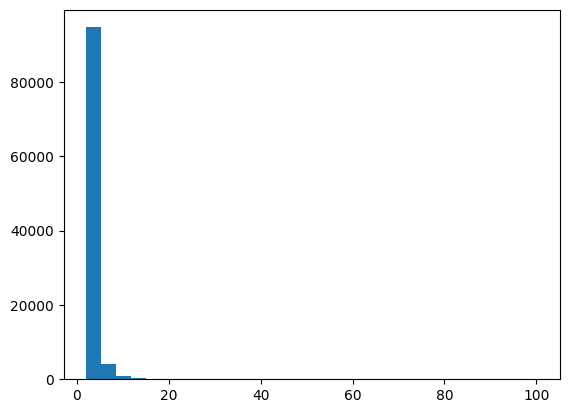

In [ ]:
# Reflection question
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Create pareto dist
a, m = 3., 2.  # pareto shape and mode
# sample_size = 1_000 # Variance of the sample mean: 0.002300
# sample_size = 5_000 # Variance of the sample mean: 0.000441
# sample_size = 10_000 # Variance of the sample mean: 0.000229
sample_size = 100_000 # Variance = 0.000028
s = (np.random.pareto(a, sample_size) + 1) * m

plt.hist(s, bins=30)

# Generate the original "full" sample from Pareto distribution
# numpy.random.pareto shifts the distribution, so we add 1 and multiply by scale
# original_data = (np.random.pareto(shape, sample_size) + 1) * scale

# Perform the bootstrap simulation
boot_repeats = 1000  # Number of bootstrap samples to make
bootstrap_means = []

for _ in range(boot_repeats):
    # Resample with replacement from our original data
    boot_sample = np.random.choice(s, size=sample_size, replace=True)
    # Calculate the mean of this resample
    boot_mean = np.mean(boot_sample)
    # Save the mean to our list
    bootstrap_means.append(boot_mean)

# Calculate the variance of all those bootstrap means
variance_of_means = np.var(bootstrap_means)

print(f"Variance of the sample mean: {variance_of_means:.6f}")